# Quy Trình Các Bước Modeling & Evaluation - SVM Regressor From Scratch

Trong phần này, chúng ta sẽ tự xây dựng mô hình Support Vector Regression (SVR) từ đầu bằng Python/NumPy, tối ưu hóa trực tiếp hàm mất mát L1 / Mean Absolute Error regularized, thử nghiệm điều chỉnh siêu tham số và so sánh hiệu năng của mô hình trước và sau khi tinh chỉnh siêu tham số trên tập kiểm thử bằng các chỉ số R², MSE, MAE, MAPE và RMSE.

Theo **Phương án A**, chúng ta giữ lại cả hai đặc trưng `Price Per Unit` và `Total Spent` để mô hình có tín hiệu học tốt nhất.

## Bước 1. Nạp Dữ Liệu Đã Tiền Xử Lý

Nạp các tập dữ liệu Train và Test đã được tiền xử lý. Theo **Phương án A**, chúng ta giữ lại cả hai đặc trưng `Price Per Unit` và `Total Spent` trước khi huấn luyện mô hình.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

# Load dữ liệu
train_df = pd.read_csv('../data/ready_train/train_ready.csv')
test_df = pd.read_csv('../data/ready_train/test_ready.csv')

# Phân tách X và y (Giữ cả hai cột Price Per Unit và Total Spent)
X_train = train_df.drop(columns=['Quantity']).values
y_train = train_df['Quantity'].values

X_test = test_df.drop(columns=['Quantity']).values
y_test = test_df['Quantity'].values

print(f'X_train shape: {X_train.shape} | y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape} | y_test shape: {y_test.shape}')

X_train shape: (9577, 16) | y_train shape: (9577,)
X_test shape: (2394, 16) | y_test shape: (2394,)


## Bước 2. Xây Dựng Lớp SVMRegressor từ đầu (From Scratch)

Mô hình tối ưu hóa trực tiếp hàm mất mát L1 regularized (Mean Absolute Error regularized):
1. **Khởi tạo Bias**: Khởi tạo bias `self.b = np.mean(y)` để đẩy nhanh quá trình hội tụ.
2. **Tối ưu hóa vector hóa**: NumPy được sử dụng để chạy Gradient Descent siêu tốc.

Dưới đây là lớp `SVMRegressor` hoàn chỉnh:

In [ ]:
class SVMRegressor:
    def __init__(self, lr=0.001, lamda=0.01, n_iters=1000):
        self.lr = lr
        self.lamda = lamda
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_sample, n_feature = X.shape
        self.w = np.zeros(n_feature)
        self.b = np.mean(y) # Khởi tạo bias bằng giá trị trung bình
        self.loss_history = []

        for _ in range(self.n_iters):
            # Dự đoán giá trị (sử dụng công thức tuyến tính thô khi huấn luyện)
            preds = X @ self.w + self.b
            errors = y - preds

            # Tính hàm mất mát J(w, b)
            reg_loss = self.lamda * np.sum(self.w ** 2)
            mae_loss = np.abs(errors)
            total_loss = reg_loss + np.mean(mae_loss)
            self.loss_history.append(total_loss)

            # Tính subgradient (vector hóa)
            grad_coef = np.where(errors < 0, 1.0, np.where(errors > 0, -1.0, 0.0))

            # Cập nhật w và b theo đạo hàm trung bình
            grad_w = 2 * self.lamda * self.w + (1.0 / n_sample) * (X.T @ grad_coef)
            grad_b = (1.0 / n_sample) * np.sum(grad_coef)

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def predict(self, X):
        raw_preds = X @ self.w + self.b
        return np.clip(raw_preds, 1.0, 15.0)

### Hàm phụ trợ tính toán các chỉ số đánh giá (Evaluation Metrics)

Định nghĩa hàm tính toán R², MSE, MAE, MAPE và RMSE.

In [3]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'R2': r2,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    }

## Bước 3. Thực Nghiệm Huấn Luyện & Điều Chỉnh Siêu Tham Số (Hyperparameter Tuning)

Đầu tiên, huấn luyện với tham số mặc định (`lr=0.001`, `lamda=0.01`, `n_iters=1000`).

In [4]:
model_default = SVMRegressor(lr=0.001, lamda=0.01, n_iters=1000)
model_default.fit(X_train, y_train)

metrics_default = evaluate_model(model_default, X_test, y_test)
print('Kết quả mô hình mặc định trên tập Test (Đã tích hợp clip):')
for k, v in metrics_default.items():
    print(f'- {k}: {v:.5f}')

Kết quả mô hình mặc định trên tập Test (Đã tích hợp clip):
- R2: 0.25093
- MSE: 6.13461
- MAE: 2.13168
- RMSE: 2.47681
- MAPE (%): 74.88358


### Tiến hành thực nghiệm lưới (Grid Search) điều chỉnh các tham số

In [5]:
# Định nghĩa dải tìm kiếm
learning_rates = [0.001, 0.005, 0.01, 0.05]
lamdas = [0.001, 0.01, 0.1]

best_r2 = -float('inf')
best_params = {}
best_model = None
results = []

for lr in learning_rates:
    for lamda in lamdas:
        model = SVMRegressor(lr=lr, lamda=lamda, n_iters=1000)
        model.fit(X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test)
        
        results.append({
            'lr': lr, 'lamda': lamda,
            'R2': metrics['R2'], 'MSE': metrics['MSE'], 'MAE': metrics['MAE']
        })
        
        if metrics['R2'] > best_r2:
            best_r2 = metrics['R2']
            best_params = {'lr': lr, 'lamda': lamda}
            best_model = model

results_df = pd.DataFrame(results)
print(f'Bộ tham số tốt nhất: {best_params}')
print(f'R2 tốt nhất trên tập Test (Đã tích hợp clip): {best_r2:.5f}')
print('\nTop 5 cấu hình có R2 cao nhất:')
display(results_df.sort_values(by='R2', ascending=False).head(5))

Bộ tham số tốt nhất: {'lr': 0.05, 'lamda': 0.001}
R2 tốt nhất trên tập Test (Đã tích hợp clip): 0.83765

Top 5 cấu hình có R2 cao nhất:


,lr,lamda,R2,MSE,MAE
9,0.05,0.001,0.837649,1.329600,0.788966
6,0.01,0.001,0.818912,1.483047,0.825554
10,0.05,0.010,0.818287,1.488163,0.825662
7,0.01,0.010,0.809523,1.559942,0.850352
11,0.05,0.100,0.699261,2.462944,1.210379


## Bước 4. Trực Quan Hóa Kết Quả (Visualization)

1. **Đường cong huấn luyện (Loss Curve)** của mô hình tốt nhất để xem mức độ hội tụ.
2. **Đồ thị phân tán Thực Tế vs Dự Báo** trên tập Test (kết quả trả về từ `predict` đã tự động được giới hạn).
3. **Biểu đồ phân phối phần dư (Residuals Distribution)**.

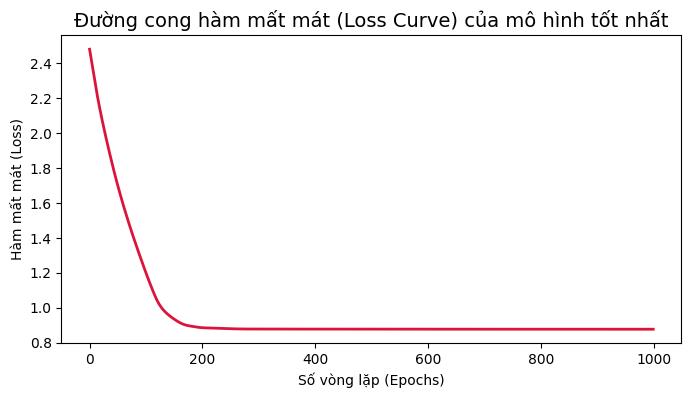

In [6]:
# 1. Đồ thị hàm mất mát Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(best_model.loss_history, color='crimson', lw=2)
plt.title('Đường cong hàm mất mát (Loss Curve) của mô hình tốt nhất', fontsize=14)
plt.xlabel('Số vòng lặp (Epochs)')
plt.ylabel('Hàm mất mát (Loss)')
plt.show()

### Biểu đồ so sánh giá trị Thực tế và giá trị Dự báo (Đã bảo đảm không có giá trị âm)

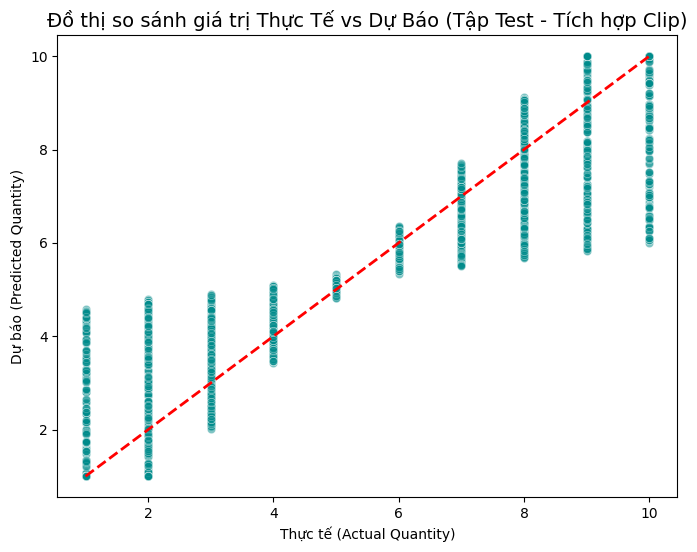

In [ ]:
y_pred_best = best_model.predict(X_test)

# 2. Scatter plot Thực tế vs Dự báo
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, color='darkcyan')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Đồ thị so sánh giá trị Thực Tế vs Dự Báo (Tập Test - Tích hợp Clip)', fontsize=14)
plt.xlabel('Thực tế (Actual Quantity)')
plt.ylabel('Dự báo (Predicted Quantity)')
plt.show()

### Phân phối sai số phần dư (Residuals)

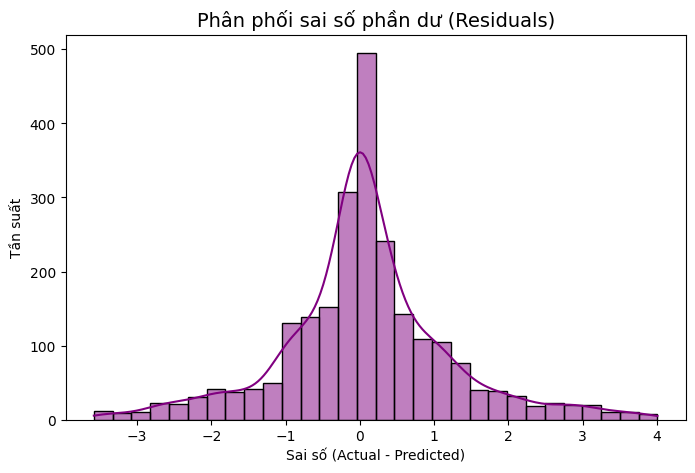

In [8]:
# 3. Phân phối phần dư
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Phân phối sai số phần dư (Residuals)', fontsize=14)
plt.xlabel('Sai số (Actual - Predicted)')
plt.ylabel('Tần suất')
plt.show()

## Bước 5. So Sánh Hiệu Năng Mô Hình Trước & Sau Khi Tinh Chỉnh (Tuning Comparison)

Bảng tổng hợp dưới đây so sánh hiệu năng của mô hình SVM Regressor từ đầu (Scratch) với cấu hình mặc định (Untuned) và sau khi được tinh chỉnh siêu tham số tối ưu (Tuned) trên tập dữ liệu kiểm thử.

In [9]:
# Lấy kết quả từ mô hình SVM tự code trước tuning (Default)
metrics_scratch_default = evaluate_model(model_default, X_test, y_test)

# Lấy kết quả từ mô hình SVM tự code sau tuning (Tuned)
metrics_scratch_tuned = evaluate_model(best_model, X_test, y_test)

# Tổng hợp bảng so sánh
comparison_df = pd.DataFrame({
    'SVM Regressor (Scratch - Untuned)': metrics_scratch_default,
    'SVM Regressor (Scratch - Tuned)': metrics_scratch_tuned
}).T

print('=== BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ===')
display(comparison_df)

=== BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ===


,R2,MSE,MAE,RMSE,MAPE (%)
SVM Regressor (Scratch - Untuned),0.250931,6.13461,2.131684,2.476815,74.883585
SVM Regressor (Scratch - Tuned),0.837649,1.32960,0.788966,1.153083,25.374891


## Bước 6. Lưu Mô Hình Đã Huấn Luyện (Save Trained Model)

Sử dụng thư viện `pickle` của Python để lưu trữ mô hình SVR tốt nhất sau khi huấn luyện thành file `.pkl` để tái sử dụng trong tương lai.

In [10]:
# Khởi tạo thư mục lưu mô hình nếu chưa tồn tại
# Luu truc tiep

# Lưu mô hình
model_path = 'best_svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Mô hình đã được lưu thành công tại: {os.path.abspath(model_path)}')

Mô hình đã được lưu thành công tại: C:\Users\Win 11\Documents\ML\ML_proj_26\lab2\modeling\best_svm_model.pkl
